In [1]:
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import os
import joblib
from sklearn.manifold import TSNE
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
seed = 42
np.random.seed(seed)

In [3]:
def read_training_set_path(file):
    """
    Args:
        file :file CSV includes paths of training set
    Returns:
        X_train: Paths of training set
        y_train: labels of training set already transfered to numeric by label_ encoder
        label_encoder: model transfer labels from "0.0", "corona", "floating", "noise", "surface", "void" to 0, 1, 2, 3, 4, 5.
    """
    #replace the "file name" of sample to the"path_of sample"
    df_paths_labels_train = pd.read_csv(file)

    # transfer to numpy array
    X_train = (df_paths_labels_train["Paths"]).values
    y_train = (df_paths_labels_train["True labels"]).values

    from collections import Counter

    class_counts = Counter(y_train)
    print(class_counts)



    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    print("Read_path_of_training_set is processing.....\n")
    return X_train, y_train, label_encoder

In [4]:
def import_one_sample(sample:str, extract_data_train):
    """
    Args:
        sample: 1 sample
        extract_data_train: data train after featuring extraction
    Returns:
        extract_data_train: data train after featuring extraction
    """
    data = np.loadtxt(
        fname = sample,
        delimiter = ","
        )
    #Feature extraction
    max_each_columns = np.max(data, axis=0)

    max_devide_nb_zeros = max_each_columns / (np.count_nonzero(data, axis=0)+1e-15)
    max_nonzeros_D3 = np.concatenate(([max_each_columns], [max_devide_nb_zeros]), axis = 0)
    extract_data = max_nonzeros_D3.reshape(1, -1)
    extract_data_train.append(extract_data)
    return extract_data_train

In [5]:
def import_train_set(X_train):
    print("Import_train_data_set is processing.....\n")
    """
    Args:
        X_train: paths of train set

    Returns:
        data_train: data  of train set
    """
    extract_data_train = []
    for sample in X_train:
        extract_data_train = import_one_sample(sample, extract_data_train)

    data_train = np.concatenate(extract_data_train, axis = 0)
    return data_train

In [6]:
def build_SVM_model(data_train, y_train ):
    print("Build_SVM_model is processing.....\n")
    """
    Args:
        data_train: data  of train set
        y_train: labels of training set already transfered to numeric by label_ encoder

    Returns:
        svm_model: SVM model made by training_set
    """
    svm_model = svm.SVC(C = 200,
        kernel= 'linear',
        gamma = 0.4e-7,
        probability = True,
        decision_function_shape='ovo',
        tol = 0.00001)

    svm_model.fit(data_train, y_train)
    print("svm_model.classes_", svm_model.classes_)

    return svm_model

In [7]:
def evaluation_metric_SVM(data_train, y_train, svm_model:object):
    print("Evaluation_metric_SVM is processing.....")
    """
    Args:
        data_train: Training data set
        y_train: True labels of training data set
        svm_model: SVM model already trained
    """
    y_predict_train = svm_model.predict(data_train)
    Accuracy_train = accuracy_score(y_train, y_predict_train)
    print(f"Training Accuracy: SVM {Accuracy_train*100}")

Counter({'Noise': 303, 'Void': 186, 'Corona': 164, 'Surface': 132, 'Turn_to_Turn': 84, 'Floating': 57})
Read_path_of_training_set is processing.....


===== CLASS DISTRIBUTION (TRAIN) =====
Class Surface: 132
Class Noise: 303
Class Turn_to_Turn: 84
Class Void: 186
Class Corona: 164
Class Floating: 57
Import_train_data_set is processing.....



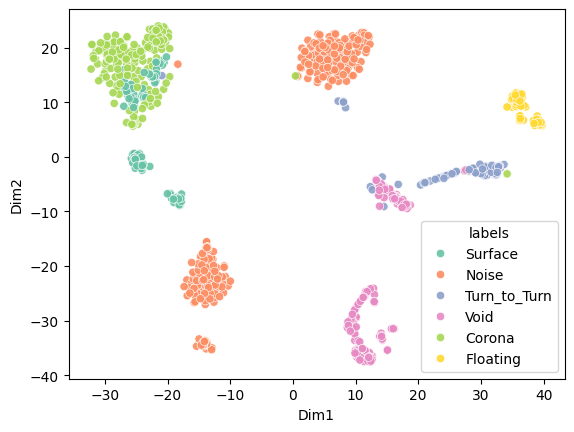

In [8]:
Paths_labels_train = "Paths_and_Labels_of_TrainingSet.csv"
X_train, y_train, label_encoder = (read_training_set_path(Paths_labels_train))

from collections import Counter
# ------------------------------
# 🟩 IN RA SỐ LƯỢNG SAMPLE THEO TỪNG CLASS
# ------------------------------
print("\n===== CLASS DISTRIBUTION (TRAIN) =====")
train_counts = Counter(y_train)
for class_idx, count in train_counts.items():
    print(f"Class {label_encoder.inverse_transform([class_idx])[0]}: {count}")



joblib.dump(label_encoder, 'SaveModel_SVM/label_encoder.joblib')

data_train = import_train_set(X_train)


model = TSNE(n_components=2, random_state=42)

tsne_data_train = model.fit_transform(data_train)
# tsne_data_test = model.transform(extract_data_test)


df_d3 = pd.DataFrame(
    {  
    "Dim1" : tsne_data_train[:,0],
    "Dim2" : tsne_data_train[:,1],
    "labels" : label_encoder.inverse_transform(y_train)
    }
)
sns.scatterplot(x=df_d3["Dim1"], y=df_d3["Dim2"], hue=df_d3["labels"], alpha=0.9, palette="Set2")
plt.show()

In [9]:
svm_model = build_SVM_model(data_train, y_train)
print("Original classes:", label_encoder.inverse_transform(svm_model.classes_))
# Lưu model ra file .joblib
joblib.dump(svm_model, 'SaveModel_SVM/svm_model.joblib')
print("SVM_ Model is saved at SaveModel_SVM/svm_model.joblib")
evaluation_metric_SVM(data_train, y_train, svm_model)

Build_SVM_model is processing.....

svm_model.classes_ [0 1 2 3 4 5]
Original classes: ['Corona' 'Floating' 'Noise' 'Surface' 'Turn_to_Turn' 'Void']
SVM_ Model is saved at SaveModel_SVM/svm_model.joblib
Evaluation_metric_SVM is processing.....
Training Accuracy: SVM 100.0
